## Import Library

In [65]:
import os
import json
import shutil
import random
from glob import glob
from pathlib import Path
from tqdm import tqdm
from PIL import Image, ImageDraw

# reproducible
RND_SEED = 77
random.seed(RND_SEED)

## GLobal Config

In [ ]:
ROOT = Path("/home/liang/workdir/NCKU-ML-25Fall/Final_Project")  
RAW_IMAGES_ROOT = ROOT / "images"      
RAW_COCO_JSON = ROOT / "annotations" / "positive_3_labels.json"  # Original COCO JSON

DATASET_DIR = ROOT / "dataset"
IMG_ALL_DIR = DATASET_DIR / "images" / "all"      # All Images
IMG_TRAIN_DIR = DATASET_DIR / "images" / "train"
IMG_VAL_DIR   = DATASET_DIR / "images" / "val"
IMG_UNLAB_DIR = DATASET_DIR / "images" / "unlabeled"
ANNOT_DIR = DATASET_DIR / "annotations"           # instances_train.json / instancejson

# train/val ratio
VAL_RATIO = 0.2

CLASS_NAMES = ["Abnormal"]

for p in [IMG_ALL_DIR, IMG_TRAIN_DIR, IMG_VAL_DIR, IMG_UNLAB_DIR, ANNOT_DIR]:
    os.makedirs(p, exist_ok=True)

print("ROOT:", ROOT)
print("RAW_IMAGES_ROOT:", RAW_IMAGES_ROOT)
print("RAW_COCO_JSON:", RAW_COCO_JSON)
print("DATASET_DIR:", DATASET_DIR)


ROOT: /home/liang/workdir/NCKU-ML-25Fall/Final_Project
RAW_IMAGES_ROOT: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/images
RAW_COCO_JSON: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/annotations/positive_3_labels.json
DATASET_DIR: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset


## Check COCO JSON Format

In [67]:
# 檢查 COCO json 是否存在且包含必要欄位
assert RAW_COCO_JSON.exists(), f"COCO json not found: {RAW_COCO_JSON}"

with open(RAW_COCO_JSON, "r", encoding="utf-8") as f:
    coco = json.load(f)

required_keys = {"images", "annotations", "categories"}
missing = required_keys - set(coco.keys())
if missing:
    raise RuntimeError(f"COCO json missing keys: {missing}")

print("COCO keys OK. #images:", len(coco["images"]), " #annotations:", len(coco["annotations"]))
# show first example
print("example image entry:", coco["images"][0])
print("example annotation entry:", coco["annotations"][0])
print("categories:", coco["categories"])


COCO keys OK. #images: 29  #annotations: 1279
example image entry: {'id': 1, 'width': 3840, 'height': 2160, 'file_name': '0.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
example annotation entry: {'id': 1, 'image_id': 1, 'category_id': 1, 'segmentation': [], 'area': 15273.70590000001, 'bbox': [2546.41, 1797.9, 128.99, 118.41], 'iscrowd': 0, 'attributes': {'occluded': False, 'rotation': 0.0}}
categories: [{'id': 1, 'name': 'Abnormal', 'supercategory': ''}]


## Collect PNG and distinguish annotated v.s. unlabled

In [68]:
# collect all png paths under RAW_IMAGES_ROOT (recursive)
all_img_paths = sorted(glob(str(RAW_IMAGES_ROOT / "all"/ "*.png"), recursive=True))
print("Found total png images:", len(all_img_paths))

# build set of filenames that appear in coco["images"]
# NOTE: COCO image file_name should be basename like 'xxx.png'
coco_filenames = {img["file_name"] for img in coco["images"]}
print("COCO lists file_count:", len(coco_filenames))

# copy images into DATASET_DIR/images/all (flatten)
for p in tqdm(all_img_paths, desc="Copying all images"):
    dest = IMG_ALL_DIR / Path(p).name
    if not dest.exists():
        shutil.copy(p, dest)

# move annotated images to dataset/images/all and mark annotated
annotated_list = []
unlabeled_list = []
for imgfile in (IMG_ALL_DIR).glob("*.png"):
    if imgfile.name in coco_filenames:
        annotated_list.append(imgfile.name)
    else:
        unlabeled_list.append(imgfile.name)

print("Annotated images:", len(annotated_list))
print("Unlabeled images:", len(unlabeled_list))

# copy annotated -> DATASET/images/all already done; we now keep file lists for splitting
# (if you want separate physical folders for annotated/unlabeled, do below)
for name in unlabeled_list:
    src = IMG_ALL_DIR / name
    dst = IMG_UNLAB_DIR / name
    if not dst.exists():
        shutil.copy(src, dst)

print("Setup complete.")


Found total png images: 503
COCO lists file_count: 29


Copying all images: 100%|██████████| 503/503 [00:00<00:00, 47911.50it/s]

Annotated images: 29
Unlabeled images: 474
Setup complete.


## Train/Test Split

In [69]:
# Prepare train/val split from annotated_list
annotated_list_sorted = sorted(annotated_list)
random.Random(RND_SEED).shuffle(annotated_list_sorted)

N = len(annotated_list_sorted)
n_val = max(1, int(N * VAL_RATIO))  # at least 1 in val
val_files = set(annotated_list_sorted[:n_val])
train_files = set(annotated_list_sorted[n_val:])

print(f"Train {len(train_files)} images, Val {len(val_files)} images (from {N} annotated)")

# copy physical files to images/train and images/val
for fname in train_files:
    src = IMG_ALL_DIR / fname
    dst = IMG_TRAIN_DIR / fname
    if not dst.exists():
        shutil.copy(src, dst)

for fname in val_files:
    src = IMG_ALL_DIR / fname
    dst = IMG_VAL_DIR / fname
    if not dst.exists():
        shutil.copy(src, dst)

print("Train/Val images copied.")


Train 24 images, Val 5 images (from 29 annotated)
Train/Val images copied.


In [70]:
# Build dicts for quick lookup
img_id_by_name = {img["file_name"]: img for img in coco["images"]}
anns_by_imgid = {}
for ann in coco["annotations"]:
    anns_by_imgid.setdefault(ann["image_id"], []).append(ann)

# build train_json and val_json
def build_coco_for_split(file_set):
    images_out = []
    annotations_out = []
    image_ids = set()
    for fname in file_set:
        if fname in img_id_by_name:
            img_info = img_id_by_name[fname]
            images_out.append(img_info)
            image_ids.add(img_info["id"])
        else:
            # warn if image listed in split but not found in original coco
            print("Warning: file", fname, "not found in COCO images list")
    # collect annotations whose image_id in image_ids
    for iid in image_ids:
        annotations_out.extend(anns_by_imgid.get(iid, []))
    # build final dict (keep licenses/info/categories if available)
    out = {}
    for k in ["licenses", "info", "categories"]:
        if k in coco:
            out[k] = coco[k]
    out["images"] = images_out
    out["annotations"] = annotations_out
    return out

train_coco = build_coco_for_split(train_files)
val_coco   = build_coco_for_split(val_files)

# write out
train_json_path = ANNOT_DIR / "instances_train.json"
val_json_path = ANNOT_DIR / "instances_val.json"
with open(train_json_path, "w", encoding="utf-8") as f:
    json.dump(train_coco, f)
with open(val_json_path, "w", encoding="utf-8") as f:
    json.dump(val_coco, f)

print("Wrote:", train_json_path, val_json_path)
print("#train images", len(train_coco["images"]), "#train anns", len(train_coco["annotations"]))
print("#val images", len(val_coco["images"]), "#val anns", len(val_coco["annotations"]))


Wrote: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset/annotations/instances_train.json /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset/annotations/instances_val.json
#train images 24 #train anns 1075
#val images 5 #val anns 204


In [71]:
# we will use path: DATASET_DIR (as string)
dataset_yaml = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    # ultralytics can optionally accept annotations path, but it will look for annotations/instances_train.json by default
    # keep names as dict index->name
    "names": {0: CLASS_NAMES[0]}
}

import yaml
yaml_path = DATASET_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(dataset_yaml, f, sort_keys=False)

print("Wrote dataset.yaml ->", yaml_path)
print(open(yaml_path).read())


Wrote dataset.yaml -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset/dataset.yaml
path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset
train: images/train
val: images/val
names:
  0: Abnormal



In [72]:
# Quick sanity: ensure every bbox fits inside its image dims
errors = 0
for img in coco["images"]:
    w = img.get("width")
    h = img.get("height")
    if w is None or h is None:
        # try to read from file
        p = IMG_ALL_DIR / img["file_name"]
        if p.exists():
            with Image.open(p) as im:
                w,h = im.size
        else:
            print("Missing image to validate size:", img["file_name"])
            continue
    for ann in anns_by_imgid.get(img["id"], []):
        x,y,bw,bh = ann["bbox"]
        if x < 0 or y < 0 or x + bw > w + 1e-3 or y + bh > h + 1e-3:
            errors += 1
            print("BBox out of bounds:", img["file_name"], ann)
print("BBox validation done. errors:", errors)


BBox validation done. errors: 0


In [73]:
from ultralytics import YOLO

# try yolov11n first, fallback if not available
preferred_weights = ["yolo11n.pt", "yolo11s.pt", "yolov10s.pt", "yolov8n.pt"]
weights = None
for w in preferred_weights:
    try:
        model = YOLO(w)
        weights = w
        break
    except Exception as e:
        # try pip installed ultralytics may still download weights; ignore and continue
        try:
            # don't crash - attempt to download from ultralytics hub via string name
            model = YOLO(w)
            weights = w
            break
        except Exception:
            continue

if weights is None:
    raise RuntimeError("Cannot load any preferred weight. Please ensure 'ultralytics' is installed and internet access available.")

print("Using weights:", weights)

# train: small quick demo settings — adjust epochs/batch/imgsz for full run
model.train(
    data=str(yaml_path),
    epochs=30,      # change to 80~200 for production
    imgsz=1024,     # choose 1024 or 1536 depending on GPU VRAM
    batch=4,
    device=0,       # or "cpu" or "cuda:0"
    name="exp_yolo11_abnormal",
    exist_ok=True
)


Using weights: yolo11n.pt
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition, 97259MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp_yolo11_abnormal, nbs=64,

/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/ultralytics/utils/metrics.py:832: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


       2/30      1.51G          0      79.51          0          0       1024: 100% ━━━━━━━━━━━━ 7/7 23.3it/s 0.3s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 60.9it/s 0.0s
                   all          5          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/ultralytics/utils/metrics.py:832: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


       3/30      1.53G          0      78.42          0          0       1024: 100% ━━━━━━━━━━━━ 7/7 21.2it/s 0.3s.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 53.9it/s 0.0s
                   all          5          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/ultralytics/utils/metrics.py:832: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Optimizer stripped from /home/liang/workdir/NCKU-ML-25Fall/Final_Project/ipynb/runs/detect/exp_yolo11_abnormal/weights/last.pt, 5.5MB
Optimizer stripped from /home/liang/workdir/NCKU-ML-25Fall/Final_Project/ipynb/runs/detect/exp_yolo11_abnormal/weights/best.pt, 5.5MB

Validating /home/liang/workdir/NCKU-ML-25Fall/Final_Project/ipynb/runs/detect/exp_yolo11_abnormal/weights/best.pt...
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition, 97259MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 64.4it/s 0.0s


/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/ultralytics/utils/metrics.py:653: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/home/liang/miniconda3/envs/ml_final/lib/python3.10/site-packa

                   all          5          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels
Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /home/liang/workdir/NCKU-ML-25Fall/Final_Project/ipynb/runs/detect/exp_yolo11_abnormal


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([], dtype=int64)
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7885b6935390>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        


image 1/1 /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset/images/val/2.png: 576x1024 (no detections), 23.3ms
Speed: 3.0ms preprocess, 23.3ms inference, 0.4ms postprocess per image at shape (1, 3, 576, 1024)


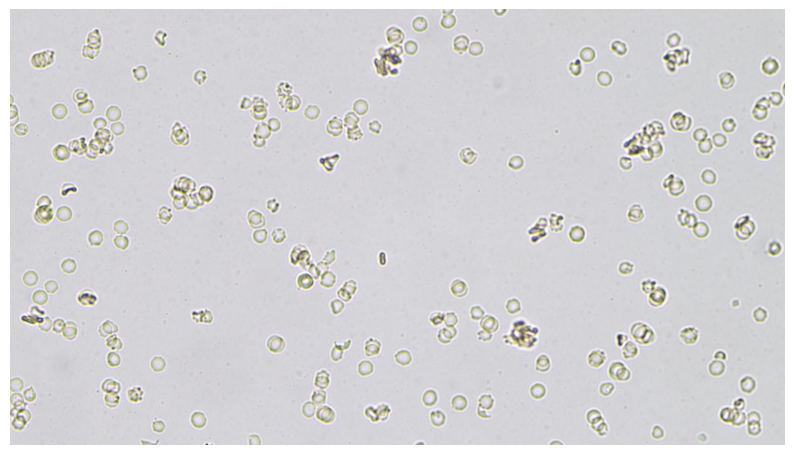

In [ ]:
# predict on a sample val image and visualize
from ultralytics import YOLO
import matplotlib.pyplot as plt

# load best model if exists
runs_dir = Path("runs")
# ultralytics will save under runs/detect/exp* or runs/train/...
# simpler: use last model from model object (model is returned from training)
# but to be robust, re-load the trained model by path if you know it; here we use model
pred = model.predict(source=str(list(IMG_VAL_DIR.glob("*.png"))[0]), save=False, imgsz=1024)
# pred is a list; show first
res = pred[0]
# plot
im = Image.open(list(IMG_VAL_DIR.glob("*.png"))[0])
plt.figure(figsize=(10,10))
plt.imshow(im)
ax = plt.gca()
for det in res.boxes.xyxy.cpu().numpy():
    x1,y1,x2,y2 = det[:4]
    rect = plt.Rectangle((x1,y1),(x2-x1),(y2-y1), fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
plt.axis('off')
plt.show()
